In [ ]:
import os
import json
import pandas as pd

# Set the folder where your city JSON files are located
json_folder = r'C:\Users\lenovo\Desktop\data_mining_project\dataset'

# Initialize an empty list to hold dataframes
df_list = []

# Loop through each JSON file in the folder
for filename in os.listdir(json_folder):
    if filename.endswith('.json'):
        file_path = os.path.join(json_folder, filename)

        # Open and load JSON data
        with open(file_path, 'r') as f:
            data = json.load(f)

        # Convert JSON to DataFrame
        df = pd.json_normalize(data)

        # Optionally add city name from filename
        city_name = filename.replace('.json', '')
        df['city'] = city_name

        # Append to the list
        df_list.append(df)

# Concatenate all DataFrames into one
full_df = pd.concat(df_list, ignore_index=True)

# Save to CSV
full_df.to_csv('us_cities_electricity_weather.csv', index=False)

print("CSV file created successfully!")


CSV file created successfully!


In [6]:
weather_df = pd.read_csv('us_cities_electricity_weather.csv')

In [7]:
weather_df.head()

,time,summary,icon,precipIntensity,precipProbability,temperature,apparentTemperature,dewPoint,humidity,pressure,windSpeed,windGust,windBearing,cloudCover,uvIndex,visibility,precipType,ozone,precipAccumulation,city
0,1530507600,Humid,clear-night,0.0,0.0,81.87,87.88,74.15,0.78,1015.6,5.45,9.31,191.0,0.01,0.0,8.479,NaN,NaN,NaN,houston
1,1530511200,Humid,clear-night,0.0,0.0,81.29,86.90,74.17,0.79,1015.4,5.30,7.54,195.0,0.00,0.0,7.880,NaN,NaN,NaN,houston
2,1530514800,Humid,clear-night,0.0,0.0,80.34,85.34,74.47,0.82,1014.9,5.49,5.49,218.0,0.00,0.0,8.751,NaN,NaN,NaN,houston
3,1530518400,Humid,clear-night,0.0,0.0,79.75,84.06,74.09,0.83,1014.8,3.53,8.39,187.0,0.01,0.0,7.772,NaN,NaN,NaN,houston
4,1530522000,Humid,clear-night,0.0,0.0,79.23,83.02,74.02,0.84,1015.0,4.25,4.25,210.0,0.05,0.0,7.772,NaN,NaN,NaN,houston


In [13]:

# Convert UNIX timestamp to datetime
weather_df['timestamp'] = pd.to_datetime(weather_df['time'], unit='s')
weather_df['city'] = weather_df['city'].str.lower().str.strip()  # normalize city names

# Load demand data
#balance_df = pd.read_csv(r'C:\Users\az848\Desktop\data_mining_project\dataset\cleaned_balance_data.csv')
#subregion_df = pd.read_csv(r'C:\Users\az848\Desktop\data_mining_project\dataset\cleaned_subregion_data.csv')

balance_df = pd.read_csv(r'/content/drive/MyDrive/dataset/cleaned_balance_data.csv')
subregion_df = pd.read_csv(r'/content/drive/MyDrive/dataset/cleaned_subregion_data.csv')


# Convert local_time to datetime
balance_df['timestamp'] = pd.to_datetime(balance_df['local_time'])
subregion_df['timestamp'] = pd.to_datetime(subregion_df['local_time'])

# Normalize city names
balance_df['city'] = balance_df['city'].str.lower().str.strip()
subregion_df['city'] = subregion_df['city'].str.lower().str.strip()

# Combine both demand dataframes
demand_df = pd.concat([balance_df[['timestamp', 'city', 'demand']],
                       subregion_df[['timestamp', 'city', 'demand']]],
                      ignore_index=True)

# Merge with the main weather dataset
merged_df = pd.merge(weather_df, demand_df, on=['timestamp', 'city'], how='left')

# Save final file
merged_df.to_csv('weather_with_demand.csv', index=False)



In [14]:
df = pd.read_csv("weather_with_demand.csv")

In [15]:
df.tail()

,time,summary,icon,precipIntensity,precipProbability,temperature,apparentTemperature,dewPoint,humidity,pressure,...,windBearing,cloudCover,uvIndex,visibility,precipType,ozone,precipAccumulation,city,timestamp,demand
165747,1590112800,Clear,clear-day,0.0,0.0,68.73,68.73,57.75,0.68,1012.1,...,269.0,0.02,0.0,10.0,NaN,312.2,NaN,san_diego,2020-05-22 02:00:00,NaN
165748,1590116400,Clear,clear-night,0.0,0.0,66.17,66.17,58.35,0.76,1012.2,...,272.0,0.02,0.0,10.0,NaN,312.1,NaN,san_diego,2020-05-22 03:00:00,NaN
165749,1590120000,Clear,clear-night,0.0,0.0,64.98,64.98,58.65,0.80,1012.6,...,267.0,0.02,0.0,10.0,NaN,312.7,NaN,san_diego,2020-05-22 04:00:00,NaN
165750,1590123600,Clear,clear-night,0.0,0.0,64.13,64.14,58.83,0.83,1013.2,...,239.0,0.02,0.0,10.0,NaN,313.7,NaN,san_diego,2020-05-22 05:00:00,NaN
165751,1590127200,Clear,clear-night,0.0,0.0,63.19,63.26,58.99,0.86,1013.1,...,228.0,0.03,0.0,10.0,NaN,314.9,NaN,san_diego,2020-05-22 06:00:00,NaN


In [16]:
# Print a quick summary
print(f"Merged dataset shape: {df.shape}")
print(f"Missing demand values: {df['demand'].isnull().sum()}")

Merged dataset shape: (165752, 22)
Missing demand values: 69158


In [17]:
missing_summary = merged_df.isnull().sum()
print(missing_summary[missing_summary > 0])


summary                   277
icon                      279
precipIntensity           230
precipProbability         230
temperature                10
apparentTemperature        10
humidity                   10
pressure                   50
windSpeed                  53
windGust                  203
windBearing                55
cloudCover                240
uvIndex                   175
visibility                172
precipType              87145
ozone                   20202
precipAccumulation     163649
demand                  69158
dtype: int64


In [18]:
# Step 1: Forward/Backward Fill for Weather Columns (by city)
weather_cols = [
    'temperature', 'apparentTemperature', 'humidity', 'pressure',
    'windSpeed', 'windGust', 'windBearing', 'cloudCover',
    'uvIndex', 'visibility', 'ozone'
]

for col in weather_cols:
    merged_df[col] = merged_df.groupby('city')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))


<ipython-input-18-41471a4ba755>:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_df[col] = merged_df.groupby('city')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
<ipython-input-18-41471a4ba755>:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_df[col] = merged_df.groupby('city')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
<ipython-input-18-41471a4ba755>:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_df[col] = merged_df.groupby('city')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
<ipython-input-18-41471a4ba755>:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffi

In [19]:
merged_df[weather_cols].isnull().sum()

,0
temperature,0
apparentTemperature,0
humidity,0
pressure,0
windSpeed,0
windGust,0
windBearing,0
cloudCover,0
uvIndex,0
visibility,0


In [ ]:
# def interpolate_demand(group):
#     group = group.set_index('timestamp')  # set timestamp as index
#     group['demand'] = group['demand'].interpolate(method='time')
#     return group.reset_index()  # restore original format

# # Apply interpolation per city
# df = df.groupby('city').apply(interpolate_demand).reset_index(drop=True)

# print("Remaining missing demand:", df['demand'].isna().sum())


In [20]:
# Fill remaining demand with forward then backward fill (per city)
df['demand'] = df.groupby('city')['demand'].transform(lambda x: x.ffill().bfill())

# Check again
print("Final missing demand:", df['demand'].isna().sum())


Final missing demand: 49722


In [21]:
# Impute remaining missing demand values with city-specific mean or median
df['demand'] = df.groupby('city')['demand'].transform(lambda x: x.fillna(x.mean()))  # or .fillna(x.median())

# Check final count of missing values
print("Remaining missing demand:", df['demand'].isna().sum())


Remaining missing demand: 49722


In [22]:
# Check the data types to ensure 'demand' is numeric
print(df.dtypes)

# Ensure 'demand' is of numeric type
df['demand'] = pd.to_numeric(df['demand'], errors='coerce')


time                     int64
summary                 object
icon                    object
precipIntensity        float64
precipProbability      float64
temperature            float64
apparentTemperature    float64
dewPoint               float64
humidity               float64
pressure               float64
windSpeed              float64
windGust               float64
windBearing            float64
cloudCover             float64
uvIndex                float64
visibility             float64
precipType              object
ozone                  float64
precipAccumulation     float64
city                    object
timestamp               object
demand                 float64
dtype: object


In [23]:
# Check cities where demand is completely missing
missing_cities = df[df['demand'].isna()]['city'].value_counts()
print(missing_cities)


city
san_antonio    16574
san_jose       16574
san_diego      16574
Name: count, dtype: int64


In [24]:
# Reset the index to avoid duplicate index issues
df = df.reset_index(drop=True)

# Now fill missing demand values for the specified cities
global_median = df['demand'].median()
df.loc[df['city'].isin(['san_antonio', 'san_diego', 'san_jose']), 'demand'] = df['demand'].fillna(global_median)

# Verify if missing values are filled
print("Remaining missing demand:", df['demand'].isna().sum())


Remaining missing demand: 0


In [25]:
print(df.isna().sum())


time                        0
summary                   277
icon                      279
precipIntensity           230
precipProbability         230
temperature                10
apparentTemperature        10
dewPoint                    0
humidity                   10
pressure                   50
windSpeed                  53
windGust                  203
windBearing                55
cloudCover                240
uvIndex                   175
visibility                172
precipType              87145
ozone                   20202
precipAccumulation     163649
city                        0
timestamp                   0
demand                      0
dtype: int64


In [26]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Alternatively, you can use the recommended method for inplace changes:
df['summary'] = df['summary'].fillna('Unknown')
df['icon'] = df['icon'].fillna('Unknown')
df['precipType'] = df['precipType'].fillna('No Precipitation')


# Verify the missing values
print("Remaining missing values after filling categorical columns:")
print(df[['summary', 'icon', 'precipType']].isna().sum())


Remaining missing values after filling categorical columns:
summary       0
icon          0
precipType    0
dtype: int64


In [27]:
# List of numerical columns with missing values
numerical_columns = ['precipIntensity', 'precipProbability', 'temperature', 'apparentTemperature',
                     'humidity', 'pressure', 'windSpeed', 'windGust', 'windBearing', 'cloudCover',
                     'uvIndex', 'visibility', 'ozone', 'precipAccumulation']

# Fill missing values for each numerical column with its median
for col in numerical_columns:
    df[col].fillna(df[col].median(), inplace=True)

# Verify if any numerical columns still have missing values
print("Remaining missing values after filling numerical columns:")
print(df[numerical_columns].isna().sum())


Remaining missing values after filling numerical columns:
precipIntensity        0
precipProbability      0
temperature            0
apparentTemperature    0
humidity               0
pressure               0
windSpeed              0
windGust               0
windBearing            0
cloudCover             0
uvIndex                0
visibility             0
ozone                  0
precipAccumulation     0
dtype: int64


In [28]:
# Extracting Time based features

# Ensure the timestamp column is in datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract time-based features
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek  # 0=Monday, 6=Sunday
df['month'] = df['timestamp'].dt.month

# Create a season feature based on month
season_mapping = {12: 'Winter', 1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring', 5: 'Spring',
                  6: 'Summer', 7: 'Summer', 8: 'Summer', 9: 'Fall', 10: 'Fall', 11: 'Fall'}
df['season'] = df['month'].map(season_mapping)


In [29]:
# Scaling Continuous Variables

from sklearn.preprocessing import MinMaxScaler, StandardScaler

# List of numerical columns to scale
numerical_columns = ['precipIntensity', 'precipProbability', 'temperature', 'apparentTemperature',
                     'humidity', 'pressure', 'windSpeed', 'windGust', 'windBearing', 'cloudCover',
                     'uvIndex', 'visibility', 'ozone', 'precipAccumulation']

# Min-Max Scaling
scaler = MinMaxScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])



In [30]:
# Check the first few rows to verify time-based features
df[['timestamp', 'hour', 'day_of_week', 'month', 'season']].head()


,timestamp,hour,day_of_week,month,season
0,2018-07-02 05:00:00,5,0,7,Summer
1,2018-07-02 06:00:00,6,0,7,Summer
2,2018-07-02 07:00:00,7,0,7,Summer
3,2018-07-02 08:00:00,8,0,7,Summer
4,2018-07-02 09:00:00,9,0,7,Summer


In [31]:
# Check the range or mean/std of scaled numerical columns
df[numerical_columns].describe()


,precipIntensity,precipProbability,temperature,apparentTemperature,humidity,pressure,windSpeed,windGust,windBearing,cloudCover,uvIndex,visibility,ozone,precipAccumulation
count,165752.000000,165752.000000,165752.000000,165752.000000,165752.000000,165752.000000,165752.000000,165752.000000,165752.000000,165752.000000,165752.000000,165752.000000,165752.000000,165752.000000
mean,0.003144,0.057698,0.539320,0.603223,0.653324,0.604069,0.214542,0.182562,0.501960,0.401023,0.115551,0.960630,0.354166,0.008875
std,0.016270,0.153479,0.143119,0.136828,0.218859,0.094148,0.126961,0.123519,0.281752,0.345429,0.194009,0.127306,0.128525,0.008467
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.439022,0.519001,0.500000,0.543645,0.117949,0.088956,0.281337,0.070000,0.000000,1.000000,0.273665,0.008611
50%,0.000000,0.000000,0.535265,0.600411,0.690000,0.594181,0.184982,0.147500,0.484680,0.320000,0.000000,1.000000,0.333808,0.008611
75%,0.001050,0.020000,0.641195,0.693397,0.830000,0.658499,0.284982,0.241589,0.738162,0.720000,0.166667,1.000000,0.413879,0.008611
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [32]:
# Aggregation

# Ensure timestamp is in datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Set timestamp as the index
df.set_index('timestamp', inplace=True)

# Aggregate daily statistics (you can change this to 'W' for weekly aggregation)
daily_summary = df.resample('D').agg({
    'precipIntensity': 'mean',
    'precipProbability': 'mean',
    'temperature': 'mean',
    'apparentTemperature': 'mean',
    'humidity': 'mean',
    'pressure': 'mean',
    'windSpeed': 'mean',
    'windGust': 'mean',
    'windBearing': 'mean',
    'cloudCover': 'mean',
    'uvIndex': 'mean',
    'visibility': 'mean',
    'ozone': 'mean',
    'precipAccumulation': 'sum'  # Sum for precipitation accumulation over the day
})

# Optional: Aggregate weekly summary
weekly_summary = df.resample('W').agg({
    'precipIntensity': 'mean',
    'precipProbability': 'mean',
    'temperature': 'mean',
    'apparentTemperature': 'mean',
    'humidity': 'mean',
    'pressure': 'mean',
    'windSpeed': 'mean',
    'windGust': 'mean',
    'windBearing': 'mean',
    'cloudCover': 'mean',
    'uvIndex': 'mean',
    'visibility': 'mean',
    'ozone': 'mean',
    'precipAccumulation': 'sum'  # Sum for precipitation accumulation over the week
})

# Display the results (Optional)
print(daily_summary.head())  # First few daily aggregated records
print(weekly_summary.head())  # First few weekly aggregated records


            precipIntensity  precipProbability  temperature  \
timestamp                                                     
2018-07-01         0.000093           0.012824     0.603894   
2018-07-02         0.000242           0.003502     0.670745   
2018-07-03         0.001716           0.011042     0.680524   
2018-07-04         0.013873           0.054083     0.667870   
2018-07-05         0.001618           0.043208     0.675830   

            apparentTemperature  humidity  pressure  windSpeed  windGust  \
timestamp                                                                  
2018-07-01             0.657723  0.604353  0.596847   0.163111  0.115131   
2018-07-02             0.727379  0.595899  0.590836   0.189046  0.116242   
2018-07-03             0.738850  0.601417  0.581272   0.199795  0.124079   
2018-07-04             0.722200  0.631333  0.600696   0.191836  0.124612   
2018-07-05             0.730921  0.651625  0.640454   0.182801  0.110354   

            windBearing  

In [33]:
import numpy as np
# Step 1: Subset the relevant features for anomaly detection
df_subset = df[['temperature', 'humidity', 'windSpeed', 'demand']]

# Step 2: Apply Z-score for anomaly detection
from scipy import stats

# Z-score method for outlier detection
z_scores = np.abs(stats.zscore(df_subset))
outliers_z_score = (z_scores > 3)  # Outliers with Z-score > 3

# Step 3: Apply IQR for anomaly detection
Q1 = df_subset.quantile(0.25)
Q3 = df_subset.quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = (df_subset < (Q1 - 1.5 * IQR)) | (df_subset > (Q3 + 1.5 * IQR))

# Step 4: Apply Isolation Forest for anomaly detection
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.01)  # Adjust contamination based on dataset characteristics
outliers_iso = iso_forest.fit_predict(df_subset)

# Convert -1 for anomalies and 1 for normal data
outliers_iso = outliers_iso == -1

# Step 5: Investigate and document anomalies for each method
# Z-score anomalies
z_outliers = df_subset[outliers_z_score.any(axis=1)]

# IQR anomalies
iqr_outliers = df_subset[outliers_iqr.any(axis=1)]

# Isolation Forest anomalies
iso_outliers = df_subset[outliers_iso]

# Display the anomalies detected by each method
print("Z-score Outliers:")
print(z_outliers.head())
print("\nIQR Outliers:")
print(iqr_outliers.head())
print("\nIsolation Forest Outliers:")
print(iso_outliers.head())


Z-score Outliers:
                     temperature  humidity  windSpeed   demand
timestamp                                                     
2018-12-20 17:00:00     0.501403      0.55   0.624542  12017.0
2018-12-20 18:00:00     0.524762      0.46   0.671062  12017.0
2018-12-20 19:00:00     0.529833      0.41   0.690842  12017.0
2018-12-20 20:00:00     0.532639      0.37   0.742857  12017.0
2018-12-20 21:00:00     0.532549      0.34   0.691575  12017.0

IQR Outliers:
                     temperature  humidity  windSpeed   demand
timestamp                                                     
2018-10-13 17:00:00     0.748846      0.63   0.535897  12017.0
2018-10-13 19:00:00     0.780534      0.56   0.548352  12017.0
2018-10-13 20:00:00     0.763241      0.58   0.582784  12017.0
2018-10-13 21:00:00     0.762426      0.58   0.541758  12017.0
2018-10-13 22:00:00     0.755455      0.61   0.535897  12017.0

Isolation Forest Outliers:
                     temperature  humidity  windSpeed   d

In [34]:
# Step 6: Handle anomalies and impute missing values

# 1. Remove rows where demand is 12432 MWh (identified as potential data entry mistakes)
df_cleaned = df[~df['demand'].isin([12432])]

# 2. Impute missing or erroneous values in other columns (temperature, humidity, windSpeed)
# We will replace missing values with the median of each column to avoid introducing bias from outliers.

# Impute missing temperature values using .loc to avoid SettingWithCopyWarning
df_cleaned.loc[:, 'temperature'] = df_cleaned['temperature'].fillna(df_cleaned['temperature'].median())

# Impute missing humidity values using .loc to avoid SettingWithCopyWarning
df_cleaned.loc[:, 'humidity'] = df_cleaned['humidity'].fillna(df_cleaned['humidity'].median())

# Impute missing windSpeed values using .loc to avoid SettingWithCopyWarning
df_cleaned.loc[:, 'windSpeed'] = df_cleaned['windSpeed'].fillna(df_cleaned['windSpeed'].median())

# 3. After imputing, check if there are any remaining missing values
missing_values = df_cleaned.isnull().sum()
print(f"Missing values after imputation:\n{missing_values}")

# 4. Recheck the dataset after cleaning and imputing
print(f"Cleaned dataset shape: {df_cleaned.shape}")

# Display the first few rows to ensure everything looks good
print(df_cleaned.head())


Missing values after imputation:
time                   0
summary                0
icon                   0
precipIntensity        0
precipProbability      0
temperature            0
apparentTemperature    0
dewPoint               0
humidity               0
pressure               0
windSpeed              0
windGust               0
windBearing            0
cloudCover             0
uvIndex                0
visibility             0
precipType             0
ozone                  0
precipAccumulation     0
city                   0
demand                 0
hour                   0
day_of_week            0
month                  0
season                 0
dtype: int64
Cleaned dataset shape: (157864, 25)
                           time summary         icon  precipIntensity  \
timestamp                                                               
2018-07-02 05:00:00  1530507600   Humid  clear-night              0.0   
2018-07-02 06:00:00  1530511200   Humid  clear-night              0.0   
2

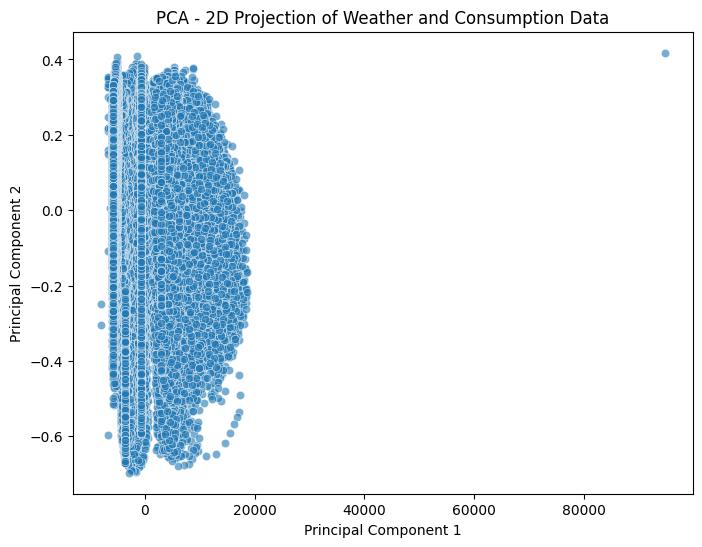

In [35]:
# Step 1: Import necessary libraries for PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Select the features for clustering (e.g., temperature, humidity, windSpeed, demand)
features = ['temperature', 'humidity', 'windSpeed', 'demand']
X = df_cleaned[features]

# Step 2: Apply PCA to reduce the data to 2 dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Step 3: Plot the results of PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], alpha=0.6)
plt.title('PCA - 2D Projection of Weather and Consumption Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


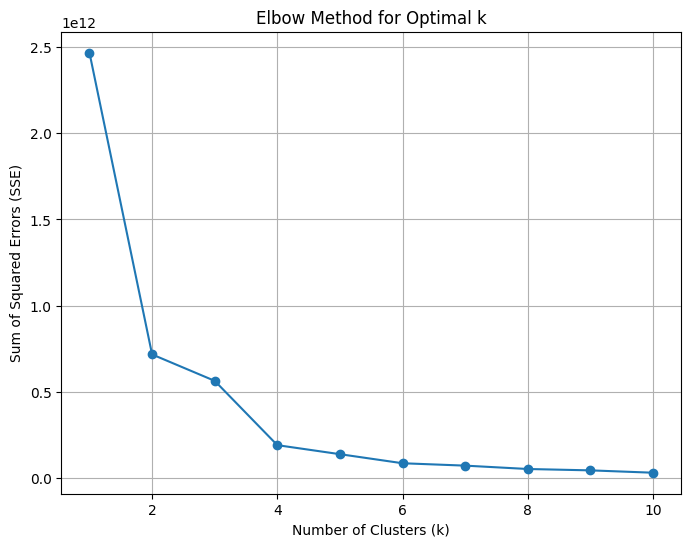

In [36]:
# Step 2: Apply K-Means and use the Elbow Method to determine the optimal number of clusters (k)
from sklearn.cluster import KMeans

# Step 1: Calculate the sum of squared distances for different values of k (1 to 10)
sse = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

# Step 2: Plot the Elbow Curve
plt.figure(figsize=(8, 6))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.grid(True)
plt.show()


In [42]:
from sklearn.cluster import KMeans

# Initialize KMeans with 4 clusters
kmeans = KMeans(n_clusters=4,random_state=42, n_init='auto')
kmeans.fit(X)
# Ensure df_cleaned is an independent copy
df_cleaned = df_cleaned.copy()

# Assuming df_cleaned is the dataframe used to generate X (after removing outliers)
df_cleaned['kmeans_cluster'] = kmeans.labels_

# Show the cluster distribution
df_cleaned['kmeans_cluster'].value_counts().sort_index()


,count
kmeans_cluster,
0,6736
1,79451
2,34955
3,36722


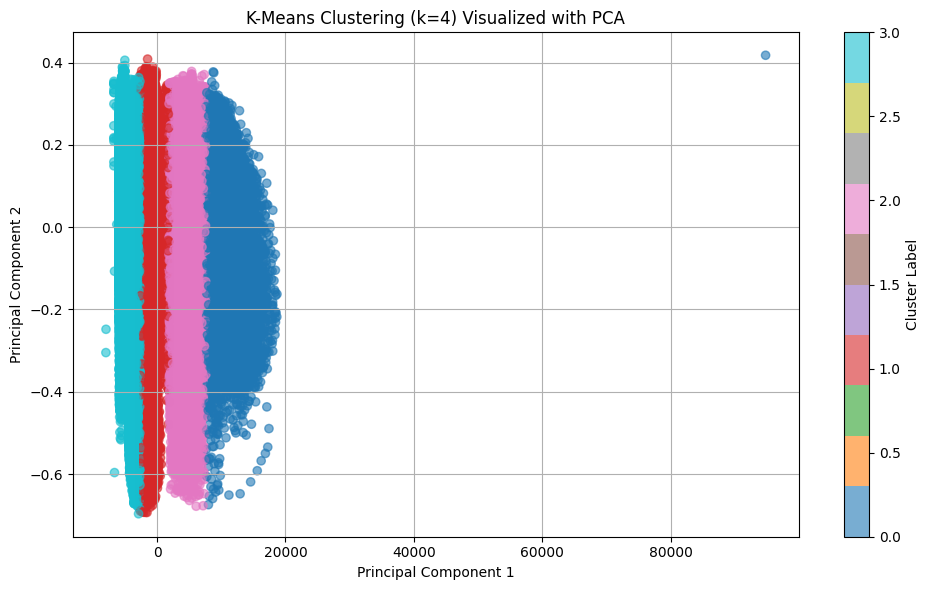

In [43]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Step 1: Apply PCA to reduce to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)  # X should be the same feature set used for KMeans

# Step 2: Plot clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_, cmap='tab10', alpha=0.6)
plt.title('K-Means Clustering (k=4) Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster Label')
plt.grid(True)
plt.tight_layout()
plt.show()


In [44]:
from sklearn.metrics import silhouette_score
import numpy as np

# Silhouette Score (higher is better)
sil_score = silhouette_score(X, kmeans.labels_)
print(f"Silhouette Score: {sil_score}")

# Cluster stability check - repeated clustering with different initializations
n_runs = 10  # Number of times to repeat clustering
stability_scores = []

for i in range(n_runs):
    kmeans_temp = KMeans(n_clusters=10, random_state=i)
    kmeans_temp.fit(X)
    stability_scores.append(silhouette_score(X, kmeans_temp.labels_))

# Average stability score across multiple runs
avg_stability_score = np.mean(stability_scores)
print(f"Average Stability Score (over {n_runs} runs): {avg_stability_score}")


Silhouette Score: 0.6947738060878658
Average Stability Score (over 10 runs): 0.7237398043245126


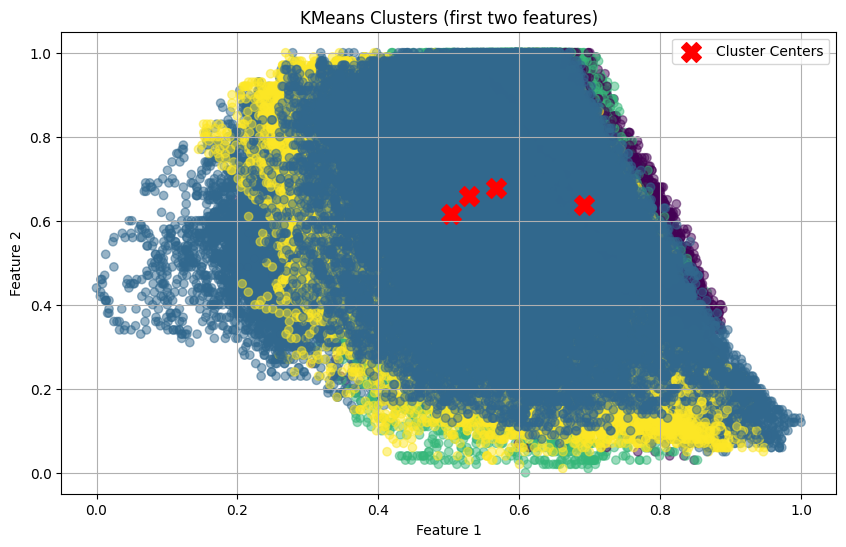

In [45]:
import matplotlib.pyplot as plt

# Convert to NumPy array
X_array = X.values

# Plot the clusters using first two dimensions
plt.figure(figsize=(10, 6))
plt.scatter(X_array[:, 0], X_array[:, 1], c=kmeans.labels_, cmap='viridis', alpha=0.5)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            marker='X', color='red', s=200, label='Cluster Centers')
plt.title("KMeans Clusters (first two features)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()


In [46]:
# Save final file
df_cleaned.to_csv('df_cleaned.csv', index=False)

In [49]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
from math import sqrt

# Using only necessary features
features = ['temperature', 'apparentTemperature', 'dewPoint', 'humidity', 'pressure',
            'precipIntensity', 'ozone', 'precipAccumulation',
            'hour', 'day_of_week', 'month', 'precipType', 'kmeans_cluster']

target = 'demand'

# One-hot encode 'season' and 'precipType' (if not already encoded)
df_model = pd.get_dummies(df_cleaned[features + [target]], columns=['precipType'], drop_first=True)

# Time-based train-test split (80% train, 20% test)
split_index = int(len(df_model) * 0.8)
X = df_model.drop(columns=[target])
y = df_model[target]
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Train XGBoost
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f" MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2%}")


 MAE: 389.15
RMSE: 495.84
MAPE: 6.53%


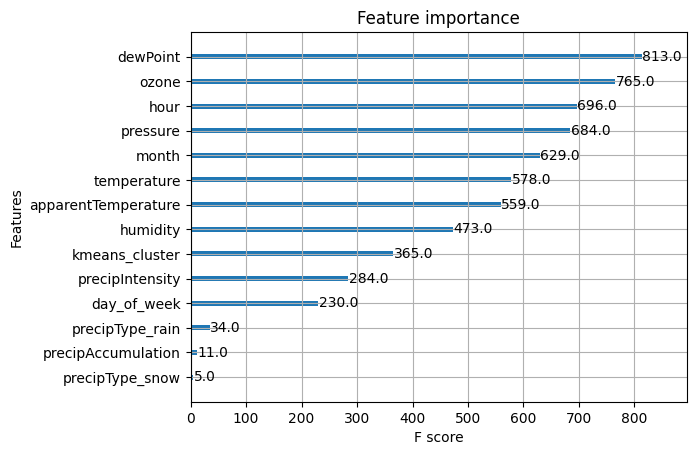

In [50]:
import matplotlib.pyplot as plt
from xgboost import plot_importance
plot_importance(model, max_num_features=15)
plt.show()

# Previously MAPE was 39% but after removing last season and precipProbability it reduced to 33.34%

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

# Ensure the data is sorted by time
df_sorted = df_cleaned.sort_index()

# Shift the 'demand' column by 24 hours (assuming hourly data)
df_sorted['naive_forecast'] = df_sorted['demand'].shift(24)

# Drop rows with NaN caused by shifting
df_baseline = df_sorted.dropna(subset=['naive_forecast'])

# True vs predicted values
y_true = df_baseline['demand']
y_pred = df_baseline['naive_forecast']

# Evaluation metrics
mae_baseline = mean_absolute_error(y_true, y_pred)
rmse_baseline = np.sqrt(mean_squared_error(y_true, y_pred))
# Mask out zero actual values to avoid division by zero
nonzero_mask = y_true != 0
mape_baseline_fixed = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100

print(f"Naive Baseline - MAE: {mae_baseline:.2f}")
print(f"Naive Baseline - RMSE: {rmse_baseline:.2f}")
print(f"Naive Baseline - MAPE: {mape_baseline_fixed:.2f}%")


Naive Baseline - MAE: 4060.11
Naive Baseline - RMSE: 5436.88
Naive Baseline - MAPE: 110.50%


In [52]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)

print(f"Random Forest - MAE: {mae_rf:.2f}")
print(f"Random Forest - RMSE: {rmse_rf:.2f}")
print(f"Random Forest - MAPE: {mape_rf:.2f}%")


Random Forest - MAE: 391.28
Random Forest - RMSE: 538.45
Random Forest - MAPE: 0.07%


## DBSCAN and Hierarchical Clustering
As part of the evaluation, we also implement DBSCAN and Hierarchical Clustering.

In [ ]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering
import numpy as np


def run_additional_clustering(data):
    print("Running DBSCAN...")
    dbscan = DBSCAN(eps=0.5, min_samples=10)
    dbscan_labels = dbscan.fit_predict(data)
    
    print("Running Hierarchical Clustering...")
    hierarchical = AgglomerativeClustering(n_clusters=4)
    hierarchical_labels = hierarchical.fit_predict(data)
    
    return dbscan_labels, hierarchical_labels


